In [1]:
import pandas as pd
import yfinance as yf
import numpy as np

# negative volatility (5-d predict)

In [2]:
spy = yf.download(['SPY'], auto_adjust=False, multi_level_index=False, start='1990-01-01')['Close'].reset_index()

spy['return'] = spy['Close'].pct_change(1)

spy['return'] = np.where(spy['return'] >= 0, 0, spy['return'])

spy['rv_t'] = spy['return'].rolling(21).std()

spy.dropna(inplace=True)

spy

[*********************100%***********************]  1 of 1 completed


,Date,Close,return,rv_t
21,1993-03-02,44.937500,0.000000,0.005721
22,1993-03-03,45.125000,0.000000,0.005721
23,1993-03-04,44.875000,-0.005540,0.005744
24,1993-03-05,44.750000,-0.002786,0.005717
25,1993-03-08,45.750000,0.000000,0.005717
...,...,...,...,...
8391,2026-06-02,759.570007,0.000000,0.002982
8392,2026-06-03,754.239990,-0.007017,0.003196
8393,2026-06-04,757.090027,0.000000,0.003196
8394,2026-06-05,737.549988,-0.025809,0.006173


<Axes: xlabel='Date'>

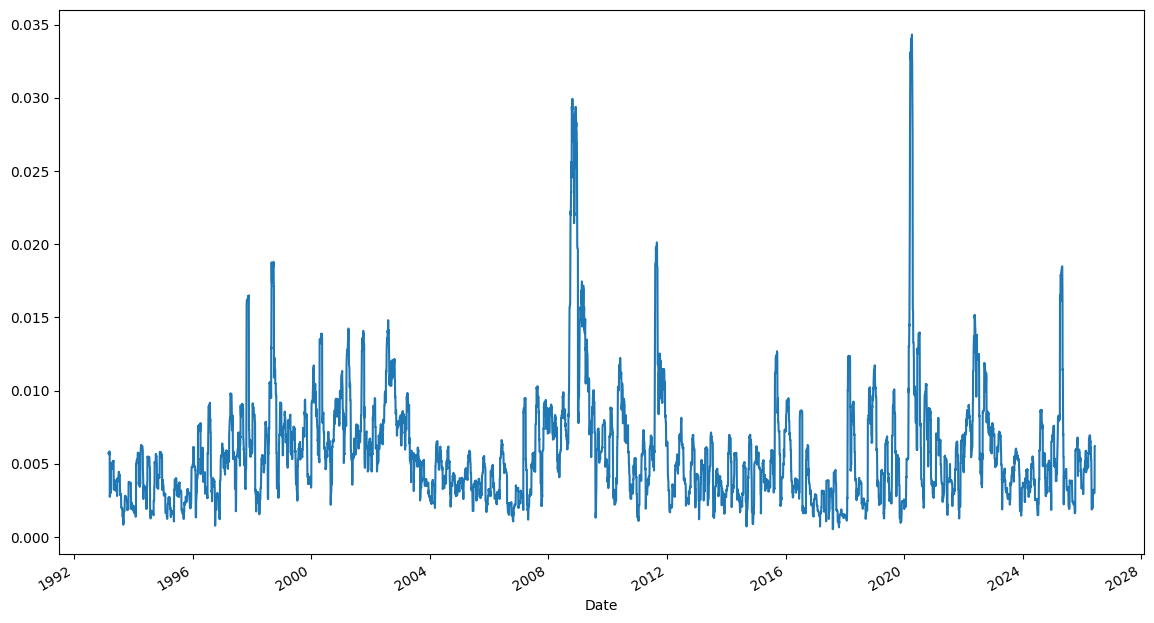

In [3]:
spy.set_index('Date')['rv_t'].plot(figsize=[14, 8])

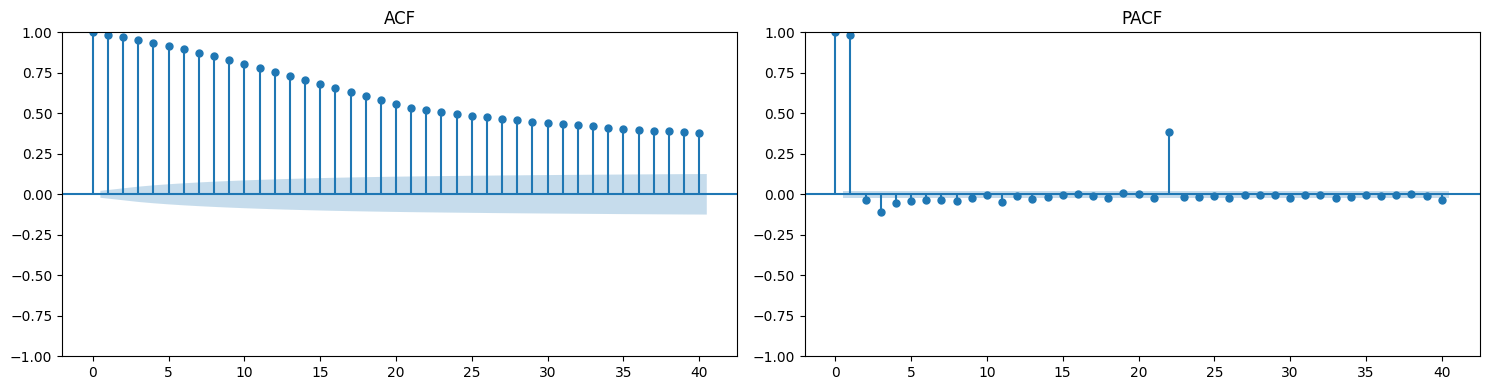

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(spy['rv_t'].dropna(), ax=axes[0], lags=40, title='ACF')
plot_pacf(spy['rv_t'].dropna(), ax=axes[1], lags=40, title='PACF', method='ywm')
plt.tight_layout()
plt.show()

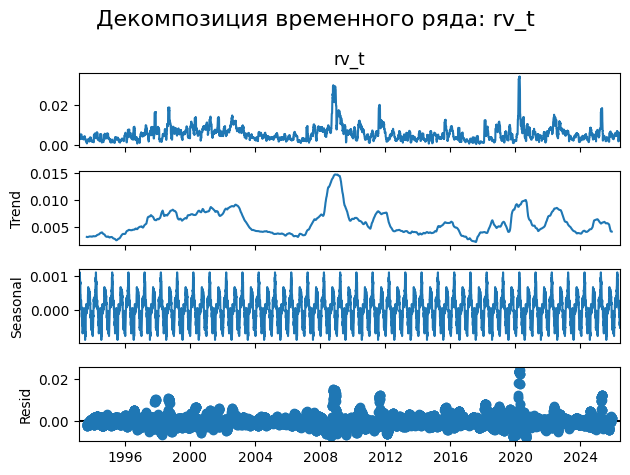

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Убедитесь, что индекс — datetime
decomp_data = spy.copy()
decomp_data['Date'] = pd.to_datetime(decomp_data['Date'])
decomp_data.set_index('Date', inplace=True)

# Декомпозиция
decomposition = seasonal_decompose(decomp_data['rv_t'].dropna(), model='additive', period=252)  # годовая сезонность (252 дня)

decomposition.plot()
plt.suptitle('Декомпозиция временного ряда: rv_t', fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

result_adf = adfuller(spy['rv_t'].dropna())

print('ADF Statistic: %f' % result_adf[0])
print('p-value: %f' % result_adf[1])
for key, value in result_adf[4].items():
    print(f'Критическое значение {key}: {value}')

ADF Statistic: -7.949670
p-value: 0.000000
Критическое значение 1%: -3.4311334844508
Критическое значение 5%: -2.8618862459816765
Критическое значение 10%: -2.5669543018861516


# Признаки

In [7]:
spy['rv_t+h'] = spy['rv_t'].shift(-5)
spy['log_rv_t+h'] = np.log(spy['rv_t+h'])
spy['log_rv_t'] = np.log(spy['rv_t'])

spy

,Date,Close,return,rv_t,rv_t+h,log_rv_t+h,log_rv_t
21,1993-03-02,44.937500,0.000000,0.005721,0.005704,-5.166651,-5.163562
22,1993-03-03,45.125000,0.000000,0.005721,0.005704,-5.166651,-5.163562
23,1993-03-04,44.875000,-0.005540,0.005744,0.005620,-5.181443,-5.159583
24,1993-03-05,44.750000,-0.002786,0.005717,0.005836,-5.143693,-5.164263
25,1993-03-08,45.750000,0.000000,0.005717,0.005836,-5.143693,-5.164263
...,...,...,...,...,...,...,...
8391,2026-06-02,759.570007,0.000000,0.002982,NaN,NaN,-5.815062
8392,2026-06-03,754.239990,-0.007017,0.003196,NaN,NaN,-5.745868
8393,2026-06-04,757.090027,0.000000,0.003196,NaN,NaN,-5.745868
8394,2026-06-05,737.549988,-0.025809,0.006173,NaN,NaN,-5.087594


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

I0000 00:00:1781084804.514022  147204 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781084804.539686  147204 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781084805.217241  147204 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [9]:
def transformer_encoder_model(
    x_train,
    y_train,
    x_val=None,
    y_val=None,
    n_heads=4,
    ff_dim=128,
    d_model=64,
    num_layers=2,
    learning_rate=3e-4,
    dropout=0.1,
    batch_size=64,
    loss='mae',
    exit_dimension=1,
    epochs=100,
    callbacks=None
):
    tf.keras.backend.clear_session()

    seq_len = x_train.shape[1]
    num_features = x_train.shape[2]

    inputs = Input(shape=(seq_len, num_features))

    # Проекция признаков в пространство d_model
    x = layers.Dense(d_model)(inputs)

    # Энкодер трансформера
    for _ in range(num_layers):
        # Self-attention
        attention_output = layers.MultiHeadAttention(
            num_heads=n_heads,
            key_dim=d_model // n_heads,
            dropout=dropout
        )(x, x)

        # Add & Norm
        x = layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

        # Feed-Forward Network
        ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(d_model),
        ])

        # FFN + Norm
        ffn_output = ffn(x)
        x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

    # Агрегация по временной оси (например, усреднение)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)

    # Выходной слой
    outputs = layers.Dense(exit_dimension, activation='linear')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss=loss)

    # Обучение
    if x_val is not None and y_val is not None:
        history = model.fit(
            x_train, y_train,
            validation_data=(x_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            shuffle=False,
            verbose=0
        )
    else:
        history = model.fit(
            x_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            shuffle=False,
            verbose=0
        )

    return model, history

## Transformer настройка

In [10]:
import optuna

import gc
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PowerTransformer
from sklearn.metrics import mean_absolute_error

In [11]:
def objective(trial):

    # 1. Гиперпараметры модели и препроцессинга
    n_heads = trial.suggest_categorical('n_heads', [4, 8, 16])
    ff_dim = trial.suggest_categorical('ff_dim', [64, 128, 256])
    d_model = trial.suggest_categorical('d_model', [32, 64, 128, 256])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    learning_rate = trial.suggest_categorical('learning_rate', [0.001, 0.0003])
    dropout = trial.suggest_categorical('dropout', [0.0, 0.2, 0.4])
    loss = trial.suggest_categorical('loss', ['log_cosh', 'mae'])
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    epochs = trial.suggest_categorical('epochs', [20, 50, 100])
    n_lags = trial.suggest_categorical('n_lags', [22, 43, 64, 85])
    scaler_name = trial.suggest_categorical('scaler', ['minmax', 'standard', 'yeo-johnson'])

    # 2. Подготовка данных
    train_df = spy[(spy.Date > '1995-01-01') & (spy.Date < '2005-01-01')].copy()
    val_df = spy[(spy.Date >= '2005-01-01') & (spy.Date < '2010-01-01')].copy()

    features = []
    for lag in range(n_lags):
        col = f'log_rv_t_lag{lag}'
        train_df[col] = train_df['log_rv_t'].shift(lag).copy()
        val_df[col] = val_df['log_rv_t'].shift(lag).copy()
        features.append(col)

    train_df.dropna(inplace=True)
    val_df.dropna(inplace=True)

    x_train = train_df[features].copy()
    y_train = train_df['log_rv_t+h'].copy()

    x_val = val_df[features].copy()
    y_val = val_df['log_rv_t+h'].copy()

    # 3. Препроцессинг
    if scaler_name == 'minmax':
        scaler = MinMaxScaler(feature_range=(-1, 1))
    elif scaler_name == 'standard':
        scaler = StandardScaler()
    elif scaler_name == 'yeo-johnson':
        scaler = PowerTransformer(method='yeo-johnson', standardize=True)
    else:
        raise ValueError(f"Unknown scaler: {scaler_name}")

    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)

    # Приведение в форму (batch, timesteps, features)
    x_train = x_train.reshape((x_train.shape[0], 1, x_train.shape[1]))
    x_val = x_val.reshape((x_val.shape[0], 1, x_val.shape[1]))

    # 4. Обучение модели
    model, history = transformer_encoder_model(
        x_train=x_train,
        y_train=y_train,
        x_val=x_val,
        y_val=y_val,
        n_heads=n_heads,
        ff_dim=ff_dim,
        d_model=d_model,
        num_layers=num_layers,
        learning_rate=learning_rate,
        dropout=dropout,
        batch_size=batch_size,
        loss=loss,
        exit_dimension=1,
        epochs=epochs
    )

    # 5. Оценка
    y_val_pred = model.predict(x_val)
    mae = mean_absolute_error(y_val, y_val_pred)

    # 6. Очистка
    del model, history, x_train, x_val, y_train, y_val, train_df, val_df, features, scaler
    gc.collect()
    tf.keras.backend.clear_session()

    return mae

In [12]:
study = optuna.create_study(
    direction='minimize',
    load_if_exists=True,
    storage="sqlite:///params_transformer.db",
    study_name="params"
)

[I 2026-06-10 14:46:46,412] Using an existing study with name 'params' instead of creating a new one.


In [13]:
study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True,
    gc_after_trial=True,
    n_jobs=1
)

  0%|          | 0/10 [00:00<?, ?it/s]

W0000 00:00:1781084808.011435  147204 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1781084808.013642  147204 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1781084808.177388  147204 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:02:00.0, compute capability: 12.0a
/home/dmitry/.local/lib/python3.12/site-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to

 1/38 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step

I0000 00:00:1781084835.940720  147332 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11081__.8
I0000 00:00:1781084835.989588  147332 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1781084836.209280  156764 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 12 bytes spill stores, 12 bytes spill loads



38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step
[I 2026-06-10 14:47:20,579] Trial 1 finished with value: 0.27348978895492027 and parameters: {'n_heads': 8, 'ff_dim': 256, 'd_model': 128, 'num_layers': 1, 'learning_rate': 0.0003, 'dropout': 0.2, 'loss': 'log_cosh', 'batch_size': 256, 'epochs': 100, 'n_lags': 64, 'scaler': 'yeo-johnson'}. Best is trial 1 with value: 0.27348978895492027.


...

 1/37 ━━━━━━━━━━━━━━━━━━━━ 33s 941ms/step

I0000 00:00:1781085035.091649  147334 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_129365__.14


37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
[I 2026-06-10 14:50:36,154] Trial 9 finished with value: 0.33890065191170976 and parameters: {'n_heads': 4, 'ff_dim': 64, 'd_model': 256, 'num_layers': 2, 'learning_rate': 0.0003, 'dropout': 0.4, 'loss': 'mae', 'batch_size': 64, 'epochs': 20, 'n_lags': 85, 'scaler': 'yeo-johnson'}. Best is trial 2 with value: 0.23467123016354222.


I0000 00:00:1781085038.939025  147336 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_136761__.78
I0000 00:00:1781085040.168261  196352 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_17', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1781085044.601489  196352 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_14', 16604 bytes spill stores, 16604 bytes spill loads

I0000 00:00:1781085044.934916  196351 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_14', 35760 bytes spill stores, 44644 bytes spill loads

I0000 00:00:1781085047.417530  196351 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_18', 3540 bytes spill stores, 3540 bytes spill loads

I0000 00:00:1781085048.322506  196352

39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
[I 2026-06-10 14:51:20,521] Trial 10 finished with value: 0.26291077837098087 and parameters: {'n_heads': 16, 'ff_dim': 128, 'd_model': 256, 'num_layers': 2, 'learning_rate': 0.001, 'dropout': 0.0, 'loss': 'log_cosh', 'batch_size': 256, 'epochs': 50, 'n_lags': 43, 'scaler': 'standard'}. Best is trial 2 with value: 0.23467123016354222.


In [14]:
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values('value', ascending=True)
trials_df.to_csv('transformer_neg_vol.csv')
trials_df

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_d_model,params_dropout,params_epochs,params_ff_dim,params_learning_rate,params_loss,params_n_heads,params_n_lags,params_num_layers,params_scaler,state
2,2,0.234671,2026-06-10 14:47:20.738754,2026-06-10 14:47:47.996900,0 days 00:00:27.258146,256,32,0.2,50,128,0.0010,log_cosh,16,43,3,minmax,COMPLETE
4,4,0.238781,2026-06-10 14:48:06.868316,2026-06-10 14:48:34.151373,0 days 00:00:27.283057,64,32,0.0,50,128,0.0003,log_cosh,4,43,3,minmax,COMPLETE
10,10,0.262911,2026-06-10 14:50:36.431285,2026-06-10 14:51:20.512337,0 days 00:00:44.081052,256,256,0.0,50,128,0.0010,log_cosh,16,43,2,standard,COMPLETE
7,7,0.270441,2026-06-10 14:49:03.961715,2026-06-10 14:49:40.788589,0 days 00:00:36.826874,64,128,0.0,100,64,0.0010,log_cosh,8,64,3,standard,COMPLETE
8,8,0.272340,2026-06-10 14:49:41.059872,2026-06-10 14:50:09.642532,0 days 00:00:28.582660,256,128,0.2,100,256,0.0003,log_cosh,4,85,2,minmax,COMPLETE
1,1,0.273490,2026-06-10 14:46:47.353724,2026-06-10 14:47:20.559735,0 days 00:00:33.206011,256,128,0.2,100,256,0.0003,log_cosh,8,64,1,yeo-johnson,COMPLETE
5,5,0.314990,2026-06-10 14:48:34.368533,2026-06-10 14:48:50.557805,0 days 00:00:16.189272,128,256,0.4,20,64,0.0003,log_cosh,4,64,1,standard,COMPLETE
9,9,0.338901,2026-06-10 14:50:09.915494,2026-06-10 14:50:36.145329,0 days 00:00:26.229835,64,256,0.4,20,64,0.0003,mae,4,85,2,yeo-johnson,COMPLETE
6,6,0.344665,2026-06-10 14:48:50.795132,2026-06-10 14:49:03.726368,0 days 00:00:12.931236,256,64,0.0,20,128,0.0010,mae,8,43,1,yeo-johnson,COMPLETE
3,3,0.380084,2026-06-10 14:47:48.193353,2026-06-10 14:48:06.673883,0 days 00:00:18.480530,128,128,0.4,20,256,0.0010,log_cosh,8,22,1,minmax,COMPLETE


In [15]:
print("Лучшие параметры:", study.best_params)
print("Лучший mae:", study.best_value)

Лучшие параметры: {'n_heads': 16, 'ff_dim': 128, 'd_model': 32, 'num_layers': 3, 'learning_rate': 0.001, 'dropout': 0.2, 'loss': 'log_cosh', 'batch_size': 256, 'epochs': 50, 'n_lags': 43, 'scaler': 'minmax'}
Лучший mae: 0.23467123016354222


## Оценка лучшей модели

In [24]:
features = []
for lag in range(43):
    spy[f'log_rv_t_lag{lag}'] = spy['log_rv_t'].shift(lag).dropna()
    features.append(f'log_rv_t_lag{lag}')

spy

,Date,Close,return,rv_t,rv_t+h,log_rv_t+h,log_rv_t,log_rv_t_lag0,log_rv_t_lag1,log_rv_t_lag2,...,log_rv_t_lag33,log_rv_t_lag34,log_rv_t_lag35,log_rv_t_lag36,log_rv_t_lag37,log_rv_t_lag38,log_rv_t_lag39,log_rv_t_lag40,log_rv_t_lag41,log_rv_t_lag42
21,1993-03-02,44.937500,0.000000,0.005721,0.005704,-5.166651,-5.163562,-5.163562,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,1993-03-03,45.125000,0.000000,0.005721,0.005704,-5.166651,-5.163562,-5.163562,-5.163562,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,1993-03-04,44.875000,-0.005540,0.005744,0.005620,-5.181443,-5.159583,-5.159583,-5.163562,-5.163562,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,1993-03-05,44.750000,-0.002786,0.005717,0.005836,-5.143693,-5.164263,-5.164263,-5.159583,-5.163562,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,1993-03-08,45.750000,0.000000,0.005717,0.005836,-5.143693,-5.164263,-5.164263,-5.164263,-5.159583,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8391,2026-06-02,759.570007,0.000000,0.002982,NaN,NaN,-5.815062,-5.815062,-5.815062,-5.815062,...,-5.032948,-5.032948,-5.039043,-4.981769,-4.984076,-4.990740,-4.990740,-4.969397,-4.985072,-4.985072
8392,2026-06-03,754.239990,-0.007017,0.003196,NaN,NaN,-5.745868,-5.745868,-5.815062,-5.815062,...,-5.032948,-5.032948,-5.032948,-5.039043,-4.981769,-4.984076,-4.990740,-4.990740,-4.969397,-4.985072
8393,2026-06-04,757.090027,0.000000,0.003196,NaN,NaN,-5.745868,-5.745868,-5.745868,-5.815062,...,-5.097768,-5.032948,-5.032948,-5.032948,-5.039043,-4.981769,-4.984076,-4.990740,-4.990740,-4.969397
8394,2026-06-05,737.549988,-0.025809,0.006173,NaN,NaN,-5.087594,-5.087594,-5.745868,-5.745868,...,-5.097334,-5.097768,-5.032948,-5.032948,-5.032948,-5.039043,-4.981769,-4.984076,-4.990740,-4.990740


In [27]:
df_pred_cv = pd.DataFrame()

for year in range(17):
    train_data_cv = spy[spy.Date < f'{2010 + year}-01-01'].dropna()
    test_data_cv = spy[(spy.Date >= f'{2010 + year}-01-01') & (spy.Date < f'{2010 + year + 1}-01-01')].dropna()

    y_train_cv = train_data_cv['log_rv_t+h']
    x_train_cv = train_data_cv[features]
    y_test_cv = test_data_cv['log_rv_t+h']
    x_test_cv = test_data_cv[features]

    scaler = MinMaxScaler(feature_range=(-1, 1))

    x_train_cv = scaler.fit_transform(x_train_cv).reshape(x_train_cv.shape[0], 1, x_train_cv.shape[1])
    x_test_cv = scaler.transform(x_test_cv).clip(-1, 1).reshape(x_test_cv.shape[0], 1, x_test_cv.shape[1])

    print('кросс валидация, год:', test_data_cv.Date.dt.year.unique())

    tf.keras.backend.clear_session()

    model, _ = transformer_encoder_model(
        x_train=x_train_cv,
        y_train=y_train_cv,
        x_val=None,
        y_val=None,
        n_heads=16,
        ff_dim=128,
        d_model=32,
        num_layers=3,
        learning_rate=0.001,
        dropout=0.2,
        batch_size=256,
        loss='log_cosh',
        exit_dimension=1,
        epochs=50,
        callbacks=None
    )

    y_pred_cv = model.predict(x_test_cv)

    cv_pred = pd.DataFrame({
        'Date': test_data_cv.index,
        'y_pred': y_pred_cv.flatten()
    })

    df_pred_cv = pd.concat([df_pred_cv, cv_pred], ignore_index=True, axis=0)

кросс валидация, год: [2010]


/home/dmitry/.local/lib/python3.12/site-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 16, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
I0000 00:00:1781086129.007065  147334 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_653541__.117
I0000 00:00:1781086132.100637  147335 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_653541__.117
/home/dmitry/.local/lib/python3.12/site-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 16, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
I0000 00:00:1781086137.787494  147335 dot_merger.cc:481] Merging Dots in computa

1/8 ━━━━━━━━━━━━━━━━━━━━ 5s 733ms/step

I0000 00:00:1781086138.556653  147333 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_657678__.20


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step
кросс валидация, год: [2011]


...

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step
кросс валидация, год: [2026]


/home/dmitry/.local/lib/python3.12/site-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 16, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
I0000 00:00:1781086421.339839  147335 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_912917__.117
I0000 00:00:1781086424.543961  147336 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_912917__.117
I0000 00:00:1781086424.653173  147336 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1781086424.872504  315944 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in fun

1/4 ━━━━━━━━━━━━━━━━━━━━ 2s 774ms/step

I0000 00:00:1781086439.128406  147335 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_919446__.20


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 681ms/step


In [28]:
model_data_test = spy[spy.Date >= '2010-01-01'].dropna()

model_data_test['y_pred'] = df_pred_cv['y_pred'].values
model_data_test['rv_t_pred'] = np.exp(model_data_test['y_pred'])
model_data_test

,Date,Close,return,rv_t,rv_t+h,log_rv_t+h,log_rv_t,log_rv_t_lag0,log_rv_t_lag1,log_rv_t_lag2,...,log_rv_t_lag35,log_rv_t_lag36,log_rv_t_lag37,log_rv_t_lag38,log_rv_t_lag39,log_rv_t_lag40,log_rv_t_lag41,log_rv_t_lag42,y_pred,rv_t_pred
4264,2010-01-04,113.330002,0.000000,0.004092,0.003338,-5.702440,-5.498628,-5.498628,-5.501446,-5.585931,...,-4.866211,-4.872481,-4.872481,-4.872481,-4.872481,-4.872481,-4.872481,-4.872481,-5.288011,0.005052
4265,2010-01-05,113.629997,0.000000,0.003918,0.003747,-5.586882,-5.542206,-5.542206,-5.498628,-5.501446,...,-4.864074,-4.866211,-4.872481,-4.872481,-4.872481,-4.872481,-4.872481,-4.872481,-5.384585,0.004587
4266,2010-01-06,113.709999,0.000000,0.003918,0.003747,-5.586882,-5.542206,-5.542206,-5.542206,-5.498628,...,-4.864074,-4.864074,-4.866211,-4.872481,-4.872481,-4.872481,-4.872481,-4.872481,-5.339840,0.004797
4267,2010-01-07,114.190002,0.000000,0.003940,0.003747,-5.586882,-5.536580,-5.536580,-5.542206,-5.542206,...,-4.856844,-4.864074,-4.864074,-4.866211,-4.872481,-4.872481,-4.872481,-4.872481,-5.347404,0.004760
4268,2010-01-08,114.570000,0.000000,0.003338,0.004241,-5.463026,-5.702440,-5.702440,-5.536580,-5.542206,...,-4.856844,-4.856844,-4.864074,-4.864074,-4.866211,-4.872481,-4.872481,-4.872481,-5.406924,0.004485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8386,2026-05-26,750.590027,0.000000,0.003063,0.002982,-5.815062,-5.788478,-5.788478,-5.788478,-5.782457,...,-4.969397,-4.985072,-4.985072,-4.998392,-4.998392,-5.001563,-5.076745,-5.173063,-5.594163,0.003720
8387,2026-05-27,750.460022,-0.000173,0.003058,0.003196,-5.745868,-5.789839,-5.789839,-5.788478,-5.788478,...,-4.990740,-4.969397,-4.985072,-4.985072,-4.998392,-4.998392,-5.001563,-5.076745,-5.591664,0.003729
8388,2026-05-28,754.599976,0.000000,0.002979,0.003196,-5.745868,-5.816150,-5.816150,-5.789839,-5.788478,...,-4.990740,-4.990740,-4.969397,-4.985072,-4.985072,-4.998392,-4.998392,-5.001563,-5.669901,0.003448
8389,2026-05-29,756.479980,0.000000,0.002982,0.006173,-5.087594,-5.815062,-5.815062,-5.816150,-5.789839,...,-4.984076,-4.990740,-4.990740,-4.969397,-4.985072,-4.985072,-4.998392,-4.998392,-5.727468,0.003255


<Axes: xlabel='Date'>

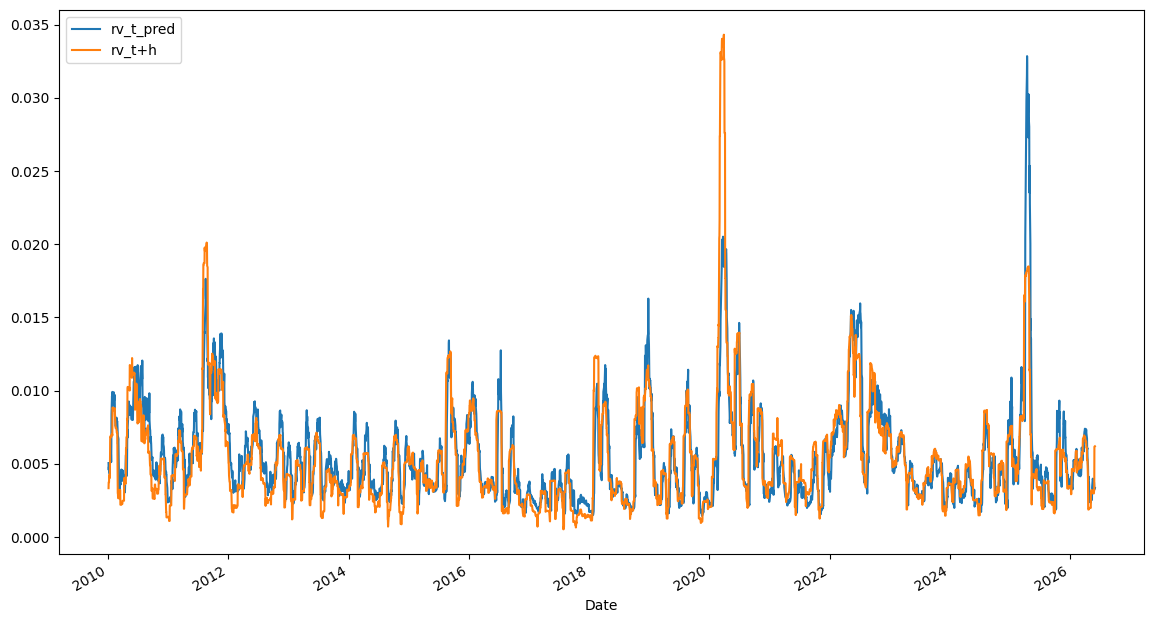

In [29]:
model_data_test.set_index('Date')[['rv_t_pred', 'rv_t+h']].plot(figsize=[14, 8])

In [30]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    max_error,
    explained_variance_score
)

In [31]:
# Истинные и предсказанные значения
y_true = model_data_test['rv_t+h'].values
y_pred = model_data_test['rv_t_pred'].values

# Метрики
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
medae = median_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
smape = np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))
max_err = max_error(y_true, y_pred)
expl_var = explained_variance_score(y_true, y_pred)

metrics_table = pd.DataFrame({
    'Метрика': ['MAE', 'MedAE', 'MSE', 'RMSE', 'R²', 'MAPE', 'SMAPE', 'Max Error', 'Explained Variance'],
    'Значение': [mae, medae, mse, rmse, r2, mape, smape, max_err, expl_var]
})

metrics_table

,Метрика,Значение
0,MAE,0.001244
1,MedAE,0.000791
2,MSE,0.000004
3,RMSE,0.002120
4,R²,0.672199
5,MAPE,0.267924
6,SMAPE,0.237331
7,Max Error,0.020061
8,Explained Variance,0.672995
